In [1]:
import adi
import numpy as np
import time
import matplotlib.pyplot as plt

In [3]:
sdr = adi.Pluto('ip:192.168.20.1')

In [4]:
fs = 1e6
fc = 1575.42e6

In [5]:
sdr.sample_rate = int(fs)
sdr.tx_rf_bandwidth = int(fs)
sdr.tx_lo = int(fc)
sdr.tx_hardwaregain_chan0 = -50 # dB
sdr.tx_destroy_buffer()

In [9]:
N = int(fs*0.05)
t = np.arange(N)/fs

data = np.random.randint(0, 2, int(N/10))
data = np.repeat(data, 10)
data = 2*data - 1
x = 0.5 * np.exp(2j*np.pi*300e3*t)
x *= data
x *= 2**14

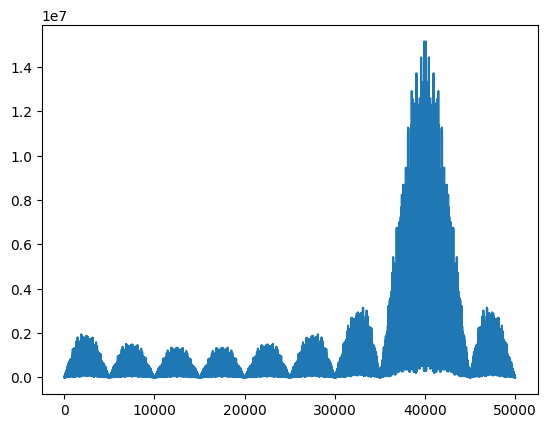

In [10]:
plt.plot(np.abs(np.fft.fftshift(np.fft.fft(x))))

In [11]:
while True:
    sdr.tx(x)

KeyboardInterrupt: 